<a href="https://colab.research.google.com/github/Halace-cmd/RDL/blob/main/RDL_Ex2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install -q datasets transformers[torch]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
from datasets import load_dataset

ag_news = load_dataset("ag_news") #https://huggingface.co/datasets/fancyzhx/ag_news
ag_news.set_format(type="pandas")
df = ag_news['train'][:]

In [21]:
df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [22]:
def label_int2str(row):
    return ag_news["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


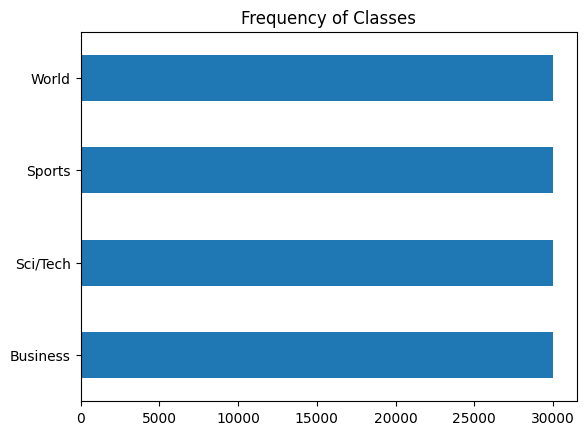

In [23]:
df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.ylabel("")
plt.show()

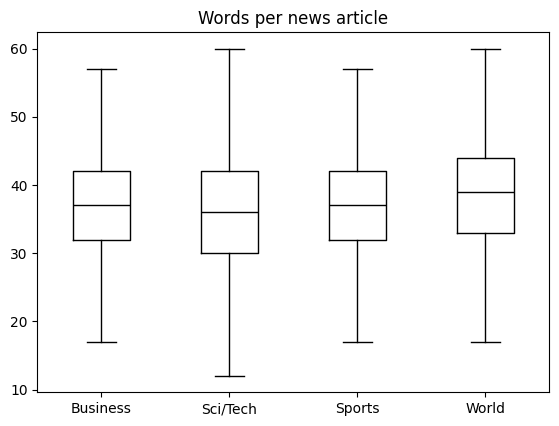

In [24]:
df["Words per news article"] = df["text"].str.split().apply(len)
df.boxplot("Words per news article", by="label_name", grid=False, showfliers=False, color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()

Reduktion der train/Test size und beibelassen von proportionen

In [25]:
ag_news.reset_format()

In [26]:
dataset_small = ag_news['train'].train_test_split(train_size=5000, test_size=2000, stratify_by_column='label', seed=42)
train = dataset_small['train']
test = dataset_small['test']

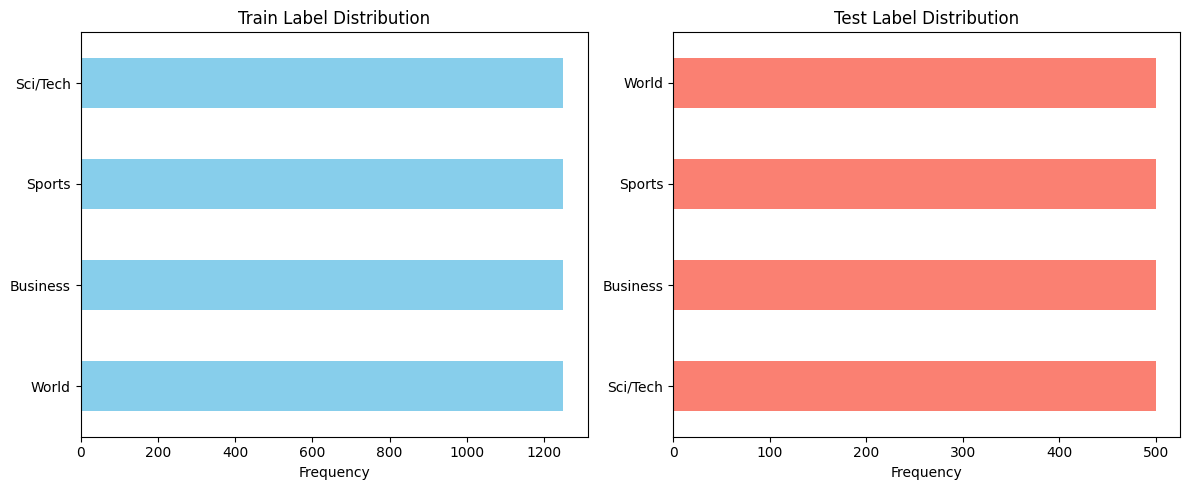

In [27]:
df_train = train.to_pandas()
df_test = test.to_pandas()

df_train['label_name'] = df_train['label'].apply(label_int2str)
df_test['label_name'] = df_test['label'].apply(label_int2str)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_train['label_name'].value_counts(ascending=True).plot.barh(ax=axes[0], color='skyblue')
axes[0].set_title('Train Label Distribution')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('')

df_test['label_name'].value_counts(ascending=True).plot.barh(ax=axes[1], color='salmon')
axes[1].set_title('Test Label Distribution')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

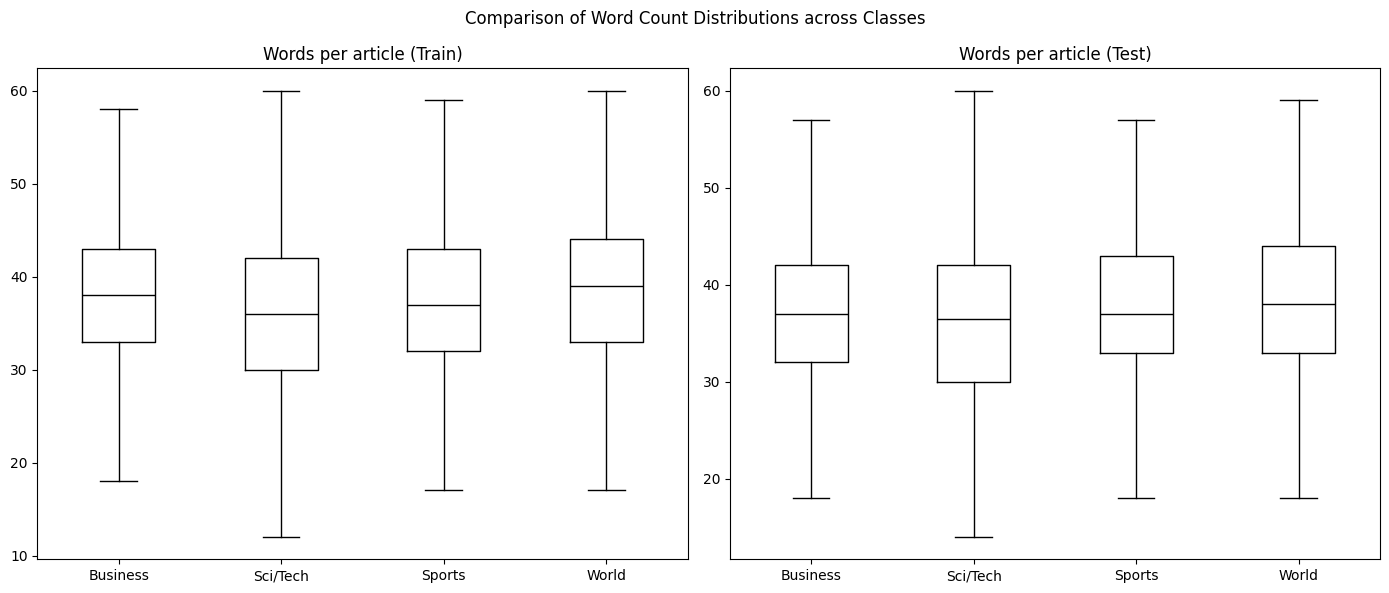

In [28]:
df_train["Words per article"] = df_train["text"].str.split().apply(len)
df_test["Words per article"] = df_test["text"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_train.boxplot("Words per article", by="label_name", grid=False, showfliers=False, ax=axes[0], color="black")
axes[0].set_title("Words per article (Train)")
axes[0].set_xlabel("")
axes[0].set_ylabel('')

df_test.boxplot("Words per article", by="label_name", grid=False, showfliers=False, ax=axes[1], color="black")
axes[1].set_title("Words per article (Test)")
axes[1].set_xlabel("")
axes[1].set_ylabel('')

plt.suptitle("Comparison of Word Count Distributions across Classes")
plt.tight_layout()
plt.show()

Tokenize

In [29]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [30]:
def tokenize(batch): # Padding ensures all sequences in a batch are the same length
    return tokenizer(batch["text"], padding="max_length", truncation=True)

tokenized_train = train.map(tokenize, batched=True)
tokenized_test = test.map(tokenize, batched=True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [31]:
tokenized_train

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})

IDs sind auf 512 sowie attention masks. ID tokens werden mit padding aufgefüllt. Attention mask für padding is dann immer 0

In [32]:
example = tokenized_train[0]

print(example['text'])
print("\nToken IDs (input_ids)")
print(example['input_ids'][:10], "...", example['input_ids'][502:])
print("\nAttention Mask")
print(example['attention_mask'][:10], "..." ,example['attention_mask'][502:])
print("\n Length of IDs and Mask", len(example['input_ids']))

Air raids hit Philippines rebels Up to 10 people are killed in air strikes on rebels in the southern island of Mindanao.

Token IDs (input_ids)
[101, 2250, 11217, 2718, 5137, 8431, 2039, 2000, 2184, 2111] ... [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Attention Mask
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ... [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

 Length of IDs and Mask 512


In [33]:
tokens2ids = list(zip(tokenizer.all_special_tokens, tokenizer.all_special_ids))
data = sorted(tokens2ids, key=lambda x : x[-1])
df = pd.DataFrame(data, columns=["Special Token", "Special Token ID"])
df.T

,0,1,2,3,4
Special Token,[PAD],[UNK],[CLS],[SEP],[MASK]
Special Token ID,0,100,101,102,103


# Train and test the model



In [34]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    # Separate the raw predictions (logits) and the true labels
    logits, labels = eval_pred
    # Get the index of the highest value (the predicted class)
    predictions = np.argmax(logits, axis=-1)

    # Calculate and return the accuracy
    accuracy = accuracy_score(labels, predictions)
    return {"accuracy": accuracy}



def compute_metrics(pred): #TODO das hier einbauen
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

In [35]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# 1. Load the pre-trained model, specifying our 4 distinct classes for AG News
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=4,
    id2label={0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"},
    label2id={"World": 0, "Sports": 1, "Business": 2, "Sci/Tech": 3}
)

# 2. Define the training arguments
training_args = TrainingArguments(
    output_dir="./ag_news_model",
    learning_rate=2e-5,                  # Standard learning rate for fine-tuning
    per_device_train_batch_size=16,      # Good batch size for Colab's Free GPU
    per_device_eval_batch_size=16,
    num_train_epochs=3,                  # 2 epochs is enough for 5k samples and keeps us under 15 mins
    weight_decay=0.01,
    fp16=True,                           # CRITICAL: Enables mixed-precision to run faster on Colab
    report_to="none"                     # Disables external logging to keep things simple
)

# 3. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

# 4. Start the fine-tuning process!
print("Starting training...")
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting training...


Step,Training Loss
500,0.383623


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=939, training_loss=0.2951770412782257, metrics={'train_runtime': 254.0469, 'train_samples_per_second': 59.044, 'train_steps_per_second': 3.696, 'total_flos': 1987081850880000.0, 'train_loss': 0.2951770412782257, 'epoch': 3.0})